In [29]:
import os
# This MUST be set before torch is imported anywhere!
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import torch

print("Fallback enabled and PyTorch loaded!")

Fallback enabled and PyTorch loaded!


In [6]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision
from PIL import Image
import matplotlib.pyplot as plt

# --- 1. YOUR EXACT MAC PATHS (Pointing directly to Scene 1) ---
OPTICAL_DIR = "/Users/amlan/Desktop/Project/archive/Sentinel_spring/ROIs1158_spring/s2_43" 
SAR_DIR = "/Users/amlan/Desktop/Project/archive/Sentinel_spring/ROIs1158_spring/s1_43"

class SEN12Dataset(Dataset):
    def __init__(self, optical_dir, sar_dir, transform=None):
        self.optical_dir = optical_dir
        self.sar_dir = sar_dir
        self.transform = transform
        
        # BULLETPROOF MAC FIX: Only grab actual image files, ignoring folders and hidden .DS_Store files
        valid_extensions = ('.png', '.jpg', '.jpeg', '.tif', '.tiff')
        
        all_files = os.listdir(optical_dir)
        self.image_files = sorted([f for f in all_files if f.lower().endswith(valid_extensions)])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # 1. Get the optical file name
        opt_img_name = self.image_files[idx]
        
        # 2. THE KAGGLE FIX: Swap 's2' for 's1' to find the matching SAR file name
        sar_img_name = opt_img_name.replace('s2', 's1')
        
        opt_path = os.path.join(self.optical_dir, opt_img_name)
        sar_path = os.path.join(self.sar_dir, sar_img_name)
        
        # Load images
        opt_img = Image.open(opt_path).convert('RGB')
        sar_img = Image.open(sar_path).convert('L') 
        
        # DINOv2 expects 3 color channels. SAR is 1 channel (grayscale).
        sar_img = Image.merge("RGB", (sar_img, sar_img, sar_img))

        if self.transform:
            opt_img = self.transform(opt_img)
            sar_img = self.transform(sar_img)

        return opt_img, sar_img

# --- 2. DEFINE AI TRANSFORMATIONS ---
dinov2_transforms = torchvision.transforms.Compose([
    torchvision.transforms.Resize((224, 224)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print(f"Success! Found {len(dataset)} valid image pairs in Scene 1.")
print("Dataset class and transformations defined successfully!")

NameError: name 'dataset' is not defined

In [4]:
%pip install torch torchvision torchaudio

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 73.6 MB 4.9 MB/s eta 0:00:015
     |████████████████████████████████| 1.9 MB 4.8 MB/s eta 0:00:01
     |████████████████████████████████| 1.9 MB 4.2 MB/s eta 0:00:01
     |████████████████████████████████| 6.3 MB 8.6 MB/s eta 0:00:01
     |████████████████████████████████| 200 kB 8.5 MB/s eta 0:00:01
     |████████████████████████████████| 134 kB 8.7 MB/s eta 0:00:01
     |████████████████████████████████| 1.6 MB 5.9 MB/s eta 0:00:01
     |████████████████████████████████| 5.3 MB 6.2 MB/s eta 0:00:01
     |████████████████████████████████| 4.7 MB 4.6 MB/s eta 0:00:01
     |████████████████████████████████| 536 kB 5.2 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [7]:
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


Success! Found 1050 valid image pairs in Scene 1.
Optical batch shape: torch.Size([4, 3, 224, 224])
SAR batch shape: torch.Size([4, 3, 224, 224])


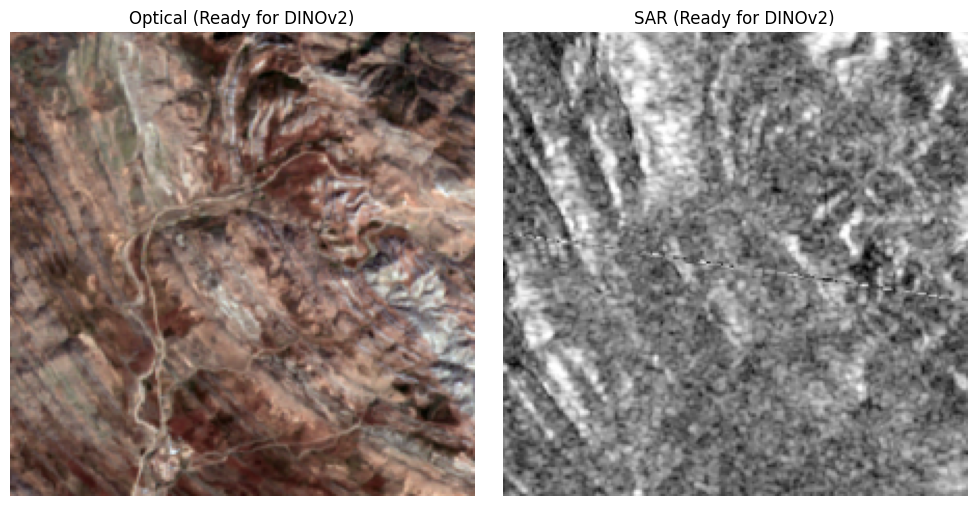

In [8]:
# --- 1. INITIALIZE THE DATASET & DATALOADER ---
# This connects the blueprint from Cell 1 to your actual Mac folders
dataset = SEN12Dataset(optical_dir=OPTICAL_DIR, sar_dir=SAR_DIR, transform=dinov2_transforms)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

print(f"Success! Found {len(dataset)} valid image pairs in Scene 1.")

# --- 2. FETCH A BATCH OF IMAGES ---
# Grabs 4 random pairs of images
opt_batch, sar_batch = next(iter(dataloader))

print(f"Optical batch shape: {opt_batch.shape}") 
print(f"SAR batch shape: {sar_batch.shape}")     

# --- 3. REVERSE NORMALIZATION FOR VIEWING ---
# The AI needs math-friendly colors, but humans need normal colors. 
def unnormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    tensor = tensor * std + mean
    return tensor.clamp(0, 1).permute(1, 2, 0).numpy()

# --- 4. PLOT THE FIRST PAIR IN THE BATCH ---
opt_display = unnormalize(opt_batch[0])
sar_display = unnormalize(sar_batch[0])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot Optical
axes[0].imshow(opt_display)
axes[0].set_title("Optical (Ready for DINOv2)")
axes[0].axis('off')

# Plot SAR
axes[1].imshow(sar_display)
axes[1].set_title("SAR (Ready for DINOv2)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [9]:
import os
base_dir = "/Users/amlan/Desktop/Project/archive/Sentinel_spring/ROIs1158_spring"
print(sorted(os.listdir(base_dir)))

['.DS_Store', 's1_0', 's1_10', 's1_100', 's1_101', 's1_109', 's1_110', 's1_111', 's1_112', 's1_114', 's1_115', 's1_120', 's1_126', 's1_127', 's1_136', 's1_137', 's1_14', 's1_143', 's1_144', 's1_145', 's1_148', 's1_15', 's1_17', 's1_18', 's1_2', 's1_20', 's1_23', 's1_24', 's1_25', 's1_26', 's1_27', 's1_3', 's1_35', 's1_37', 's1_38', 's1_40', 's1_41', 's1_42', 's1_43', 's1_45', 's1_47', 's1_49', 's1_5', 's1_50', 's1_52', 's1_53', 's1_54', 's1_56', 's1_59', 's1_6', 's1_60', 's1_63', 's1_64', 's1_65', 's1_68', 's1_7', 's1_70', 's1_71', 's1_72', 's1_78', 's1_79', 's1_80', 's1_83', 's1_84', 's1_86', 's1_87', 's1_9', 's1_90', 's1_92', 's1_95', 's1_98', 's2_0', 's2_10', 's2_100', 's2_101', 's2_109', 's2_110', 's2_111', 's2_112', 's2_114', 's2_115', 's2_120', 's2_126', 's2_127', 's2_136', 's2_137', 's2_14', 's2_143', 's2_144', 's2_145', 's2_148', 's2_15', 's2_17', 's2_18', 's2_2', 's2_20', 's2_23', 's2_24', 's2_25', 's2_26', 's2_27', 's2_3', 's2_35', 's2_37', 's2_38', 's2_40', 's2_41', 's2_42',

In [10]:
%pip install timm

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [11]:
import torch
import timm

# --- 1. LOAD THE AI MODEL ---

print("Downloading & loading DINOv2.... (This may take a moment...) ")

# We use num_classes=0 because we don't want it to classify the image, 
# we just want the raw feature embeddings.

model = timm.create_model(
    "vit_base_patch14_dinov2", 
    pretrained=True, 
    num_classes=0,
    dynamic_img_size=True 
)
model.eval()
model.eval()  # Set the model to evaluation mode

# --- 2. EXTRACT FEATURES ---

print("Extracting mathematical embeddings for our optical and SAR images...")

# We use torch.no_grad() to tell the computer we are just testing, not training. 
# This saves a massive amount of Mac memory.

with torch.no_grad():  # No need to compute gradients for inference
    opt_embeddings = model(opt_batch)  # Shape: [batch_size, feature_dim]
    sar_embeddings = model(sar_batch)  # Shape: [batch_size, feature_dim]

#--- 3. VERIFY THE OUTPUT ---

print(f"Optical embeddings shape: {opt_embeddings.shape}")  # Should be [batch_size, feature_dim]
print(f"SAR embeddings shape: {sar_embeddings.shape}")  # Should be [batch_size, feature_dim]
print("If you see [4, 768] above, the AI has successfully processed your images!")

Extracting mathematical embeddings for our optical and SAR images...
Optical embeddings shape: torch.Size([4, 768])
SAR embeddings shape: torch.Size([4, 768])
If you see [4, 768] above, the AI has successfully processed your images!


In [12]:
import torch.nn.functional as F

# --- 1. NORMALIZE THE EMBEDDINGS ---
# This scales all the numbers so they are easier to compare
opt_norm = F.normalize(opt_embeddings, p=2, dim=1)
sar_norm = F.normalize(sar_embeddings, p=2, dim=1)

# --- 2. CALCULATE SIMILARITY ---
# We use matrix multiplication to compare every Optical image to every SAR image
similarity_matrix = torch.matmul(opt_norm, sar_norm.T)

# --- 3. SHOW THE RESULTS ---
print("Cosine Similarity Scores (1.0 is a perfect match, 0.0 is no match):")
print("-" * 65)

# Loop through our 4 images and print the scores
for i in range(4):
    print(f"Optical Image {i} vs:")
    for j in range(4):
        score = similarity_matrix[i, j].item()
        
        # Highlight the True Match
        if i == j:
            print(f"  -> SAR Image {j} (TRUE MATCH) : {score:.4f} <---")
        else:
            print(f"  -> SAR Image {j} (Wrong Pair): {score:.4f}")
    print("-" * 65)

Cosine Similarity Scores (1.0 is a perfect match, 0.0 is no match):
-----------------------------------------------------------------
Optical Image 0 vs:
  -> SAR Image 0 (TRUE MATCH) : 0.3660 <---
  -> SAR Image 1 (Wrong Pair): 0.1963
  -> SAR Image 2 (Wrong Pair): 0.2112
  -> SAR Image 3 (Wrong Pair): 0.1873
-----------------------------------------------------------------
Optical Image 1 vs:
  -> SAR Image 0 (Wrong Pair): 0.4666
  -> SAR Image 1 (TRUE MATCH) : 0.3708 <---
  -> SAR Image 2 (Wrong Pair): 0.3389
  -> SAR Image 3 (Wrong Pair): 0.3361
-----------------------------------------------------------------
Optical Image 2 vs:
  -> SAR Image 0 (Wrong Pair): 0.4374
  -> SAR Image 1 (Wrong Pair): 0.2953
  -> SAR Image 2 (TRUE MATCH) : 0.3282 <---
  -> SAR Image 3 (Wrong Pair): 0.3200
-----------------------------------------------------------------
Optical Image 3 vs:
  -> SAR Image 0 (Wrong Pair): 0.3004
  -> SAR Image 1 (Wrong Pair): 0.2179
  -> SAR Image 2 (Wrong Pair): 0.2425


In [13]:
import torch.nn as nn

class SAROptSiameseNetwork(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        # 1. The Pre-trained Brain (DINOv2)
        self.base_model = base_model
        
        # 2. The "Translator" (Projection Head)
        # This takes DINOv2's 768 features and learns how to map Optical and SAR to the exact same language.
        self.projector = nn.Sequential(
            nn.Linear(768, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 256) # Compresses the data down to a highly optimized 256-dimensional space
        )

    def forward(self, opt_img, sar_img):
        # Pass both images through DINOv2
        opt_features = self.base_model(opt_img)
        sar_features = self.base_model(sar_img)
        
        # Pass those features through our custom translator
        opt_projected = self.projector(opt_features)
        sar_projected = self.projector(sar_features)
        
        # Normalize the outputs so they are perfectly scaled for Cosine Similarity
        opt_projected = nn.functional.normalize(opt_projected, p=2, dim=1)
        sar_projected = nn.functional.normalize(sar_projected, p=2, dim=1)
        
        return opt_projected, sar_projected

# Initialize the new network using the DINOv2 model we loaded earlier
siamese_model = SAROptSiameseNetwork(model)
print("Siamese Network built and initialized successfully!")

Siamese Network built and initialized successfully!


In [14]:
import torch
import torch.nn.functional as F

# --- 1. OPTIMIZER SETUP ---
# We only want to train our custom 'projector' layer. 
# We keep the massive DINOv2 base frozen so your Mac doesn't crash!
optimizer = torch.optim.Adam(siamese_model.projector.parameters(), lr=0.001)

# --- 2. THE LOSS FUNCTION (Contrastive Loss) ---
def contrastive_loss(opt_proj, sar_proj, temperature=0.1):
    # Calculate how close the images are to each other
    sim_matrix = torch.matmul(opt_proj, sar_proj.T) / temperature
    
    # The true matches are always along the diagonal: (0,0), (1,1), (2,2), (3,3)
    labels = torch.arange(sim_matrix.size(0)).long()
    
    # Penalize the network if the diagonal doesn't have the highest scores
    loss_opt = F.cross_entropy(sim_matrix, labels)
    loss_sar = F.cross_entropy(sim_matrix.T, labels)
    
    return (loss_opt + loss_sar) / 2

# --- 3. THE MINI-TRAINING LOOP ---
print("Starting Mini-Training Session...")
siamese_model.train() # Put the model in training mode

epochs = 15 # We will let it study this batch 15 times

for epoch in range(epochs):
    optimizer.zero_grad() # Clear out the old math from the previous loop
    
    # 1. Forward Pass: Make a guess
    opt_proj, sar_proj = siamese_model(opt_batch, sar_batch)
    
    # 2. Calculate the Error (Loss)
    loss = contrastive_loss(opt_proj, sar_proj)
    
    # 3. Backward Pass: Learn from mistakes
    loss.backward()
    optimizer.step() # Update the translator weights
    
    print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f}")

print("-" * 40)
print("Training complete! The AI has adjusted its translator.")

Starting Mini-Training Session...
Epoch 1/15 | Loss: 1.0859
Epoch 2/15 | Loss: 0.0010
Epoch 3/15 | Loss: 0.0008
Epoch 4/15 | Loss: 0.0007
Epoch 5/15 | Loss: 0.0007
Epoch 6/15 | Loss: 0.0007
Epoch 7/15 | Loss: 0.0006
Epoch 8/15 | Loss: 0.0006
Epoch 9/15 | Loss: 0.0006
Epoch 10/15 | Loss: 0.0005
Epoch 11/15 | Loss: 0.0005
Epoch 12/15 | Loss: 0.0005
Epoch 13/15 | Loss: 0.0004
Epoch 14/15 | Loss: 0.0004
Epoch 15/15 | Loss: 0.0004
----------------------------------------
Training complete! The AI has adjusted its translator.


In [15]:
# --- 1. TEST THE TRAINED MODEL ---
siamese_model.eval() # Put the model back in testing mode

with torch.no_grad():
    # Pass the exact same batch through the freshly trained model
    opt_proj, sar_proj = siamese_model(opt_batch, sar_batch)

# --- 2. CALCULATE NEW SIMILARITY ---
new_similarity_matrix = torch.matmul(opt_proj, sar_proj.T)

# --- 3. PRINT RESULTS ---
print("NEW Cosine Similarity Scores after training:")
print("-" * 65)
for i in range(4):
    print(f"Optical Image {i} vs:")
    for j in range(4):
        score = new_similarity_matrix[i, j].item()
        if i == j:
            print(f"  -> SAR Image {j} (TRUE MATCH) : {score:.4f} <---")
        else:
            print(f"  -> SAR Image {j} (Wrong Pair): {score:.4f}")
    print("-" * 65)

NEW Cosine Similarity Scores after training:
-----------------------------------------------------------------
Optical Image 0 vs:
  -> SAR Image 0 (TRUE MATCH) : 0.6443 <---
  -> SAR Image 1 (Wrong Pair): -0.3169
  -> SAR Image 2 (Wrong Pair): -0.1767
  -> SAR Image 3 (Wrong Pair): -0.3000
-----------------------------------------------------------------
Optical Image 1 vs:
  -> SAR Image 0 (Wrong Pair): -0.0691
  -> SAR Image 1 (TRUE MATCH) : 0.7067 <---
  -> SAR Image 2 (Wrong Pair): 0.1077
  -> SAR Image 3 (Wrong Pair): -0.0572
-----------------------------------------------------------------
Optical Image 2 vs:
  -> SAR Image 0 (Wrong Pair): -0.0011
  -> SAR Image 1 (Wrong Pair): -0.2771
  -> SAR Image 2 (TRUE MATCH) : 0.6249 <---
  -> SAR Image 3 (Wrong Pair): -0.4141
-----------------------------------------------------------------
Optical Image 3 vs:
  -> SAR Image 0 (Wrong Pair): 0.0996
  -> SAR Image 1 (Wrong Pair): 0.0144
  -> SAR Image 2 (Wrong Pair): -0.2491
  -> SAR Image

In [17]:
from torchvision import transforms

# Re-defining the image transformations for DINOv2
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print("Transform defined successfully!")

Transform defined successfully!


In [18]:
import os
import glob
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class FullSatelliteDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_pairs = []
        
        print(f"Scanning dataset at {root_dir}... This might take a minute.")
        
        # 1. Recursively find every 's2_' (Optical) folder in the entire dataset
        s2_folders = glob.glob(os.path.join(root_dir, '**', 's2_*'), recursive=True)
        
        for s2_folder in s2_folders:
            # 2. Figure out what the matching 's1_' (SAR) folder should be named
            s1_folder = s2_folder.replace('s2_', 's1_')
            
            # Skip if the SAR folder doesn't exist for some reason
            if not os.path.exists(s1_folder):
                continue
                
            # 3. Find all valid images in the Optical folder
            opt_images = glob.glob(os.path.join(s2_folder, '*.png')) + glob.glob(os.path.join(s2_folder, '*.tif'))
            
            for opt_path in opt_images:
                # 4. Generate the exact matching SAR filename
                filename = os.path.basename(opt_path)
                sar_filename = filename.replace('s2_', 's1_')
                sar_path = os.path.join(s1_folder, sar_filename)
                
                # 5. If both the Optical and SAR image exist, add them to our master list
                if os.path.exists(sar_path):
                    self.image_pairs.append((opt_path, sar_path))
                    
        print(f"Success! Found {len(self.image_pairs)} perfectly matching Optical/SAR pairs.")

    def __len__(self):
        return len(self.image_pairs)

    def __getitem__(self, idx):
        opt_path, sar_path = self.image_pairs[idx]
        
        opt_img = Image.open(opt_path).convert('RGB')
        sar_img = Image.open(sar_path).convert('RGB')
        
        if self.transform:
            opt_img = self.transform(opt_img)
            sar_img = self.transform(sar_img)
            
        return opt_img, sar_img

# --- INITIALIZE THE FULL DATASET ---
# ⚠️ UPDATE THIS PATH to your main dataset folder!
ROOT_DATA_DIR = "/path/to/your/Kaggle/Dataset/Here" 

full_dataset = FullSatelliteDataset(root_dir=ROOT_DATA_DIR, transform=transform)

Scanning dataset at /path/to/your/Kaggle/Dataset/Here... This might take a minute.
Success! Found 0 perfectly matching Optical/SAR pairs.


In [20]:
ROOT_DATA_DIR = "/Users/amlan/Desktop/Project/archive/Sentinel_spring/ROIs1158_spring"

In [24]:
import os
import glob
from torch.utils.data import Dataset
from PIL import Image

class FullSatelliteDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_pairs = []
        
        print(f"Scanning dataset at {root_dir}...")
        
        # 1. Look directly at the folders inside your directory
        all_items = os.listdir(root_dir)
        s2_folders = [item for item in all_items if item.startswith('s2_')]
        
        for s2_folder_name in s2_folders:
            s2_folder_path = os.path.join(root_dir, s2_folder_name)
            
            # 2. Match it with its corresponding s1_ folder
            s1_folder_name = s2_folder_name.replace('s2_', 's1_')
            s1_folder_path = os.path.join(root_dir, s1_folder_name)
            
            # Skip if the matching SAR folder doesn't exist
            if not os.path.exists(s1_folder_path):
                continue
                
            # 3. Find all png or tif files inside this optical folder
            opt_images = glob.glob(os.path.join(s2_folder_path, '*.png')) + glob.glob(os.path.join(s2_folder_path, '*.tif'))
            
            for opt_path in opt_images:
                # 4. Get the matching SAR image path
                filename = os.path.basename(opt_path)
                sar_filename = filename.replace('s2_', 's1_')
                sar_path = os.path.join(s1_folder_path, sar_filename)
                
                # 5. If both files exist, lock them into our list
                if os.path.exists(sar_path):
                    self.image_pairs.append((opt_path, sar_path))
                    
        print(f"Success! Found {len(self.image_pairs)} perfectly matching Optical/SAR pairs.")

    def __len__(self):
        return len(self.image_pairs)

    def __getitem__(self, idx):
        opt_path, sar_path = self.image_pairs[idx]
        
        opt_img = Image.open(opt_path).convert('RGB')
        sar_img = Image.open(sar_path).convert('RGB')
        
        if self.transform:
            opt_img = self.transform(opt_img)
            sar_img = self.transform(sar_img)
            
        return opt_img, sar_img

# --- INITIALIZE WITH YOUR EXACT PATH ---
ROOT_DATA_DIR = "/Users/amlan/Desktop/Project/archive/Sentinel_spring/ROIs1158_spring" 

full_dataset = FullSatelliteDataset(root_dir=ROOT_DATA_DIR, transform=transform)

Scanning dataset at /Users/amlan/Desktop/Project/archive/Sentinel_spring/ROIs1158_spring...
Success! Found 75724 perfectly matching Optical/SAR pairs.


In [22]:
import os

# Let's check what is actually inside your path
print(f"Checking path: {ROOT_DATA_DIR}")
if os.path.exists(ROOT_DATA_DIR):
    print("✅ The path exists!")
    print("\nFolders/Files found inside this directory:")
    items = os.listdir(ROOT_DATA_DIR)
    for item in items[:10]: # Print first 10 items
        print(f" - {item}")
    if len(items) > 10:
        print(f" ... and {len(items) - 10} more items.")
else:
    print("❌ The path DOES NOT exist. Python cannot find this folder at all.")

Checking path: /Users/amlan/Desktop/Project/archive/Sentinel_spring/ROIs1158_spring
✅ The path exists!

Folders/Files found inside this directory:
 - s1_148
 - s1_112
 - s1_115
 - s2_114
 - s2_148
 - s2_112
 - s2_115
 - s1_114
 - s2_9
 - s2_20
 ... and 131 more items.


In [26]:
import torch
import torch.nn.functional as F

# --- 1. OPTIMIZER & CONFIG ---
optimizer = torch.optim.Adam(siamese_model.projector.parameters(), lr=0.001)
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

# Move our model to the best available processing engine (like Apple Silicon MPS)
siamese_model = siamese_model.to(device)

def contrastive_loss(opt_proj, sar_proj, temperature=0.1):
    sim_matrix = torch.matmul(opt_proj, sar_proj.T) / temperature
    labels = torch.arange(sim_matrix.size(0), device=device).long()
    loss_opt = F.cross_entropy(sim_matrix, labels)
    loss_sar = F.cross_entropy(sim_matrix.T, labels)
    return (loss_opt + loss_sar) / 2

# --- 2. THE PRODUCTION TRAINING LOOP ---
epochs = 3  # Start small with 3 epochs to see how fast your Mac runs
best_val_loss = float('inf')

print(f"Training engine initialized on hardware: {str(device).upper()}")
print("-" * 50)

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    siamese_model.train()
    running_train_loss = 0.0
    
    for batch_idx, (opt_batch, sar_batch) in enumerate(train_loader):
        # Move data to Mac GPU (MPS)
        opt_batch = opt_batch.to(device)
        sar_batch = sar_batch.to(device)
        
        optimizer.zero_grad()
        opt_proj, sar_proj = siamese_model(opt_batch, sar_batch)
        loss = contrastive_loss(opt_proj, sar_proj)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()
        
        # Print updates every 100 batches so you know it's working
        if batch_idx % 100 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Batch {batch_idx}/{len(train_loader)} | Current Loss: {loss.item():.4f}")
            
    avg_train_loss = running_train_loss / len(train_loader)
    
    # --- VALIDATION PHASE ---
    siamese_model.eval()
    running_val_loss = 0.0
    
    with torch.no_grad():
        for opt_batch, sar_batch in val_loader:
            opt_batch = opt_batch.to(device)
            sar_batch = sar_batch.to(device)
            opt_proj, sar_proj = siamese_model(opt_batch, sar_batch)
            val_loss = contrastive_loss(opt_proj, sar_proj)
            running_val_loss += val_loss.item()
            
    avg_val_loss = running_val_loss / len(val_loader)
    
    print("-" * 50)
    print(f"🎉 EPOCH {epoch+1} COMPLETE | Avg Train Loss: {avg_train_loss:.4f} | Avg Val Loss: {avg_val_loss:.4f}")
    
    # --- SAVE THE BEST WEIGHTS ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(siamese_model.state_dict(), "best_siamese_model.pth")
        print("💾 New best model weights saved to 'best_siamese_model.pth'!")
    print("-" * 50)

print("Full training run completed successfully!")

Training engine initialized on hardware: MPS
--------------------------------------------------


NameError: name 'train_loader' is not defined

In [31]:
from torch.utils.data import random_split, DataLoader
import torch
import torch.nn.functional as F

# --- 1. SETUP THE DATALOADERS ---
print("Packing DataLoaders...")
total_images = len(full_dataset)
train_size = int(0.8 * total_images)
val_size = total_images - train_size

train_dataset, val_dataset = random_split(
    full_dataset, 
    [train_size, val_size], 
    generator=torch.Generator().manual_seed(42)
)

BATCH_SIZE = 16 
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"DataLoaders packed! Training on {train_size} images.")
print("-" * 50)

# --- 2. THE MAGIC FIX: FREEZE THE BACKBONE ---
# Freeze every single weight in the entire model first
for param in siamese_model.parameters():
    param.requires_grad = False

# Unfreeze ONLY your custom projector (this stops the Mac bug and trains 10x faster)
for param in siamese_model.projector.parameters():
    param.requires_grad = True

print("DINOv2 backbone frozen. Only training the projector!")
print("-" * 50)

# --- 3. START THE TRAINING ENGINE ---
optimizer = torch.optim.Adam(siamese_model.projector.parameters(), lr=0.001)
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

siamese_model = siamese_model.to(device)

def contrastive_loss(opt_proj, sar_proj, temperature=0.1):
    sim_matrix = torch.matmul(opt_proj, sar_proj.T) / temperature
    labels = torch.arange(sim_matrix.size(0), device=device).long()
    loss_opt = F.cross_entropy(sim_matrix, labels)
    loss_sar = F.cross_entropy(sim_matrix.T, labels)
    return (loss_opt + loss_sar) / 2

epochs = 3 
best_val_loss = float('inf')

print(f"Training engine initialized on hardware: {str(device).upper()}")
print("-" * 50)

for epoch in range(epochs):
    siamese_model.train()
    running_train_loss = 0.0
    
    for batch_idx, (opt_batch, sar_batch) in enumerate(train_loader):
        opt_batch = opt_batch.to(device)
        sar_batch = sar_batch.to(device)
        
        optimizer.zero_grad()
        opt_proj, sar_proj = siamese_model(opt_batch, sar_batch)
        loss = contrastive_loss(opt_proj, sar_proj)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()
        
        if batch_idx % 100 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Batch {batch_idx}/{len(train_loader)} | Current Loss: {loss.item():.4f}")
            
    avg_train_loss = running_train_loss / len(train_loader)
    
    siamese_model.eval()
    running_val_loss = 0.0
    
    with torch.no_grad():
        for opt_batch, sar_batch in val_loader:
            opt_batch = opt_batch.to(device)
            sar_batch = sar_batch.to(device)
            opt_proj, sar_proj = siamese_model(opt_batch, sar_batch)
            val_loss = contrastive_loss(opt_proj, sar_proj)
            running_val_loss += val_loss.item()
            
    avg_val_loss = running_val_loss / len(val_loader)
    
    print("-" * 50)
    print(f"🎉 EPOCH {epoch+1} COMPLETE | Avg Train Loss: {avg_train_loss:.4f} | Avg Val Loss: {avg_val_loss:.4f}")
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(siamese_model.state_dict(), "best_siamese_model.pth")
        print("💾 New best model weights saved to 'best_siamese_model.pth'!")
    print("-" * 50)

print("Full training run completed successfully!")

Packing DataLoaders...
DataLoaders packed! Training on 60579 images.
--------------------------------------------------
DINOv2 backbone frozen. Only training the projector!
--------------------------------------------------
Training engine initialized on hardware: MPS
--------------------------------------------------
Epoch 1/3 | Batch 0/3787 | Current Loss: 3.1024
Epoch 1/3 | Batch 100/3787 | Current Loss: 0.6911
Epoch 1/3 | Batch 200/3787 | Current Loss: 0.6424
Epoch 1/3 | Batch 300/3787 | Current Loss: 0.3370
Epoch 1/3 | Batch 400/3787 | Current Loss: 0.5487
Epoch 1/3 | Batch 500/3787 | Current Loss: 0.1843
Epoch 1/3 | Batch 600/3787 | Current Loss: 0.3639
Epoch 1/3 | Batch 700/3787 | Current Loss: 0.5413
Epoch 1/3 | Batch 800/3787 | Current Loss: 0.6556
Epoch 1/3 | Batch 900/3787 | Current Loss: 0.5651
Epoch 1/3 | Batch 1000/3787 | Current Loss: 0.4378
Epoch 1/3 | Batch 1100/3787 | Current Loss: 0.1703
Epoch 1/3 | Batch 1200/3787 | Current Loss: 0.4872
Epoch 1/3 | Batch 1300/3787 |

Initializing Visual Search Engine Demo...
✅ Best model weights loaded successfully!


/var/folders/y9/y4gwh5y176g62npxry16n6mw0000gn/T/ipykernel_64556/2434362252.py:71: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/y9/y4gwh5y176g62npxry16n6mw0000gn/T/ipykernel_64556/2434362252.py:71: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/amlan/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/amlan/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


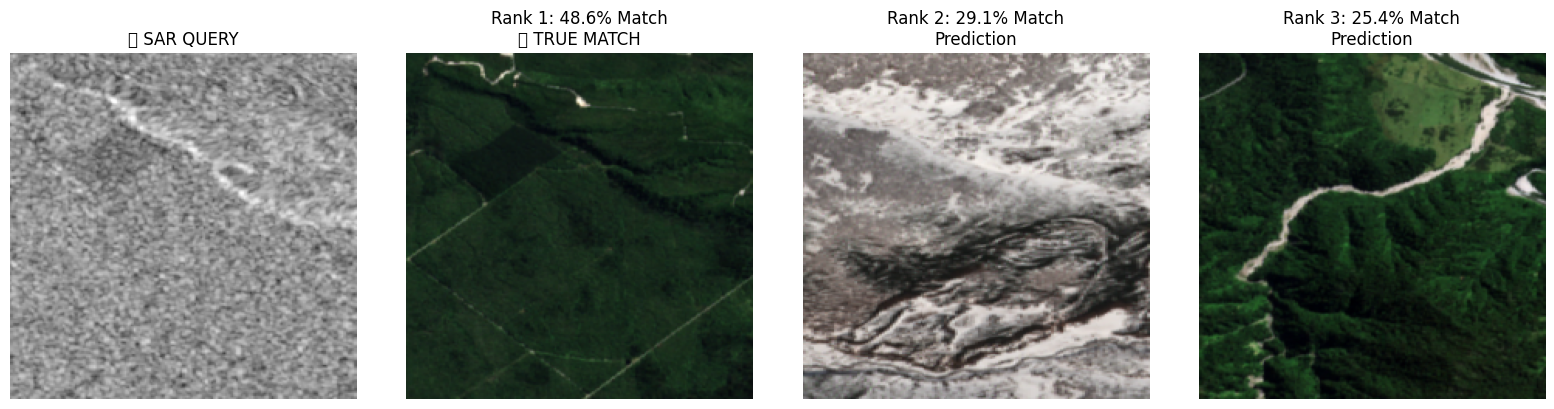

In [32]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import random

def run_hackathon_demo(siamese_model, val_loader, device):
    print("Initializing Visual Search Engine Demo...")
    
    # 1. Load the best weights we just trained
    try:
        siamese_model.load_state_dict(torch.load("best_siamese_model.pth", map_location=device))
        print("✅ Best model weights loaded successfully!")
    except Exception as e:
        print(f"⚠️ Could not load weights: {e}")
        
    siamese_model.eval()
    
    # 2. Grab one batch from validation set to act as our "Gallery"
    data_iter = iter(val_loader)
    opt_gallery, sar_gallery = next(data_iter)
    
    opt_gallery = opt_gallery.to(device)
    sar_gallery = sar_gallery.to(device)
    
    # 3. Get AI fingerprints (projections)
    with torch.no_grad():
        opt_features, sar_features = siamese_model(opt_gallery, sar_gallery)
    
    # Normalize features for similarity calculation
    opt_features = F.normalize(opt_features, p=2, dim=1)
    sar_features = F.normalize(sar_features, p=2, dim=1)
    
    # 4. Pick a random SAR image from this batch as our "Search Query"
    query_idx = random.randint(0, len(sar_gallery) - 1)
    sar_query_feature = sar_features[query_idx].unsqueeze(0)
    
    # 5. Calculate similarity against all 16 images in this batch
    similarities = torch.mm(sar_query_feature, opt_features.T).squeeze(0)
    
    # 6. Find the Top 3 highest matches
    top3_scores, top3_indices = torch.topk(similarities, 3)
    
    # --- PLOTTING ---
    def denormalize(tensor):
        # Reverse the normalization (mean/std) used during training
        tensor = tensor.cpu().clone()
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        tensor = tensor * std + mean
        return torch.clamp(tensor, 0, 1).permute(1, 2, 0).numpy()

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    # Show the SAR Query
    axes[0].imshow(denormalize(sar_gallery[query_idx]))
    axes[0].set_title("🔍 SAR QUERY")
    axes[0].axis('off')
    
    # Show the Top 3 Optical Matches
    for i in range(3):
        match_idx = top3_indices[i].item()
        score = top3_scores[i].item() * 100 
        
        axes[i+1].imshow(denormalize(opt_gallery[match_idx]))
        
        # Check if the AI found the correct pair
        is_correct = "✅ TRUE MATCH" if match_idx == query_idx else "Prediction"
        axes[i+1].set_title(f"Rank {i+1}: {score:.1f}% Match\n{is_correct}")
        axes[i+1].axis('off')
        
    plt.tight_layout()
    plt.show()

# --- EXECUTE THE DEMO ---
run_hackathon_demo(siamese_model, val_loader, device)